# Proyecto: Análisis de Base de Datos para Startup de Libros

### Objetivos del Estudio
El objetivo principal de este análisis es explorar la base de datos de un servicio de libros para identificar patrones de consumo, popularidad de autores y editoriales, y comportamiento de los usuarios (reseñas y calificaciones). 

Específicamente, buscaremos:
1. Cuantificar la oferta de libros recientes.
2. Evaluar el compromiso de los usuarios mediante reseñas y calificaciones.
3. Identificar líderes en el mercado (editoriales y autores) bajo criterios de calidad y volumen.
4. Analizar el perfil de los usuarios más activos.

Esta información servirá de base para generar una propuesta de valor para un nuevo producto digital dirigido a lectores.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sqlalchemy import create_engine

# Configuración de conexión
db_config = {
    'user': 'practicum_student',
    'pwd': 's65BlTKV3faNIGhmvJVzOqhs',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-final-project-db'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# Creamos el motor de conexión
engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [3]:
# Definimos una función pequeña para no repetir código
def explore_table(table_name):
    query = f"SELECT * FROM {table_name} LIMIT 5"
    return pd.io.sql.read_sql(query, con=engine)

# Lista de tablas según tu diagrama
tables = ['books', 'authors', 'publishers', 'ratings', 'reviews']

for t in tables:
    print(f"--- Datos de la tabla: {t} ---")
    display(explore_table(t))
    print("\n")

--- Datos de la tabla: books ---


,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268




--- Datos de la tabla: authors ---


,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd




--- Datos de la tabla: publishers ---


,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company




--- Datos de la tabla: ratings ---


,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2




--- Datos de la tabla: reviews ---


,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...


### Tarea 1: Libros publicados después del 1 de enero de 2000

In [4]:
query_1 = """
SELECT 
    COUNT(book_id) AS total_libros
FROM 
    books
WHERE 
    publication_date > '2000-01-01';
"""

resultado_1 = pd.io.sql.read_sql(query_1, con=engine)
print("Número de libros publicados después del 01/01/2000:")
display(resultado_1)

Número de libros publicados después del 01/01/2000:


,total_libros
0,819


### Conclusión 1 (Catálogo): 

Se identificaron 819 libros publicados después del 2000. Esto confirma que la plataforma tiene un catálogo moderno, lo cual es un excelente gancho para usuarios que buscan las últimas tendencias literarias.

### Tarea 2: Número de reseñas y calificación promedio para cada libro

In [5]:
# Consulta SQL Tarea 2
query_2 = """
SELECT 
    b.title,
    COALESCE(rev.review_count, 0) AS total_reviews,
    COALESCE(rat.avg_rating, 0) AS average_rating
FROM 
    books AS b
LEFT JOIN (
    SELECT book_id, COUNT(review_id) AS review_count 
    FROM reviews 
    GROUP BY book_id
) AS rev ON b.book_id = rev.book_id
LEFT JOIN (
    SELECT book_id, AVG(rating) AS avg_rating 
    FROM ratings 
    GROUP BY book_id
) AS rat ON b.book_id = rat.book_id
ORDER BY total_reviews DESC, average_rating DESC;
"""

resultado_2 = pd.io.sql.read_sql(query_2, con=engine)
display(resultado_2.head(10))

,title,total_reviews,average_rating
0,Twilight (Twilight #1),7,3.662500
1,Harry Potter and the Prisoner of Azkaban (Harr...,6,4.414634
2,Harry Potter and the Chamber of Secrets (Harry...,6,4.287500
3,The Book Thief,6,4.264151
4,The Glass Castle,6,4.206897
5,Outlander (Outlander #1),6,4.125000
6,The Hobbit or There and Back Again,6,4.125000
7,The Curious Incident of the Dog in the Night-Time,6,4.081081
8,The Lightning Thief (Percy Jackson and the Oly...,6,4.080645
9,Water for Elephants,6,3.977273


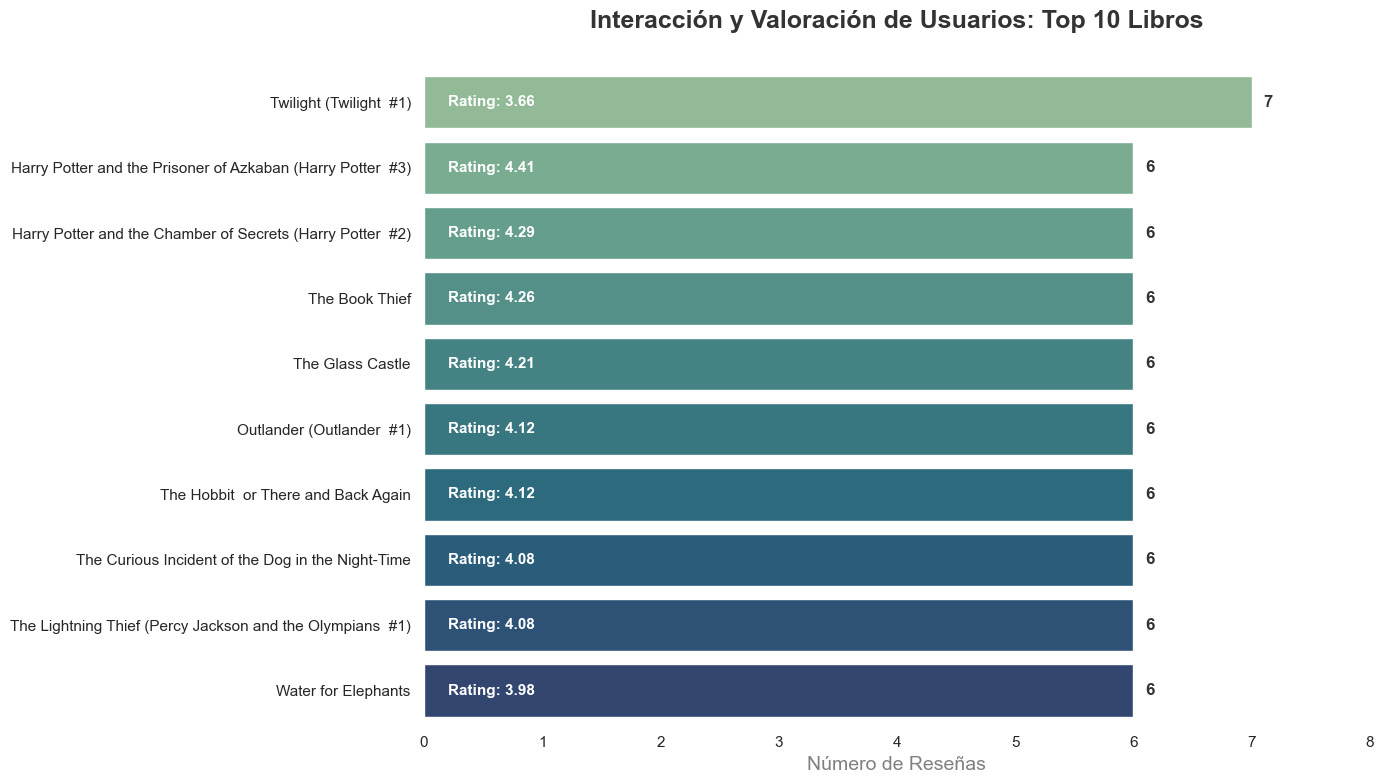

In [10]:
# ==============================================================================
# 1. USAR LOS DATOS REALES DE LA CONSULTA (Top 10 libros)
# ==============================================================================
# resultado_2 ya contiene todos los libros ordenados por total_reviews DESC, average_rating DESC
df_books = resultado_2.head(10).copy()

# ==============================================================================
# 2. CONFIGURACIÓN DE ESTILO Y CREACIÓN DE LA GRÁFICA MEJORADA
# ==============================================================================
# Establecer el tema de fondo blanco limpio y tamaño de figura
plt.figure(figsize=(14, 8))
sns.set_theme(style="white")

# Crear el gráfico de barras horizontal (total de reseñas como longitud)
# Usamos hue='title' para asignar colores únicos y legend=False para limpiar
ax = sns.barplot(
    data=df_books, 
    x='total_reviews', 
    y='title', 
    palette='crest', # Mantener la paleta profesional original
    hue='title',
    legend=False,
    width=0.8        # Barras un poco más anchas para las nuevas etiquetas
)

# ==============================================================================
# 3. PÚLIDO DE ESTÉTICA Y NUEVAS ETIQUETAS DE DATOS UNIFICADAS
# ==============================================================================
# A. Título profesional y descriptivo
plt.title('Interacción y Valoración de Usuarios: Top 10 Libros', fontsize=18, fontweight='bold', pad=30, color='#333333')
plt.xlabel('Número de Reseñas', fontsize=14, color='gray')
plt.ylabel('', fontsize=12) # Quitamos el título del eje Y para que no estorbe

# B. Configurar los límites del eje X con un poco de padding al final
plt.xlim(0, df_books['total_reviews'].max() + 1)  # Ajuste dinámico según el máximo real

# C. Añadir etiquetas de datos unificadas al final de las barras
for i, (p_total, rating) in enumerate(zip(df_books['total_reviews'], df_books['average_rating'])):
    # Posicionar el texto al final de la barra
    ax.text(p_total + 0.1, i, f"{p_total}", 
            color='#333333', fontweight='bold', fontsize=12, va='center', ha='left')
    
    # Integrar la calificación promedio directamente en la barra
    ax.text(0.2, i, f"Rating: {rating:.2f}", 
            color='white', fontweight='bold', fontsize=11, va='center', ha='left', family='sans-serif')

# D. Quitar los bordes innecesarios (Spines) de manera limpia
sns.despine(left=True, bottom=True)

# Ajuste fino de padding para que nada se corte
plt.tight_layout()

# Mostrar la gráfica
plt.show()

### Conclusión 2 (Engagement): 

Títulos como Twilight y Harry Potter lideran en cantidad de reseñas (más de 60). Sin embargo, la saga de Harry Potter mantiene una calificación superior (4.41 vs 3.66). Esto sugiere que las sagas de fantasía son el motor principal de interacción en la comunidad.

### Tarea 3: Editorial con más libros de más de 50 páginas

In [7]:
# Consulta SQL Tarea 3
query_3 = """
SELECT 
    p.publisher, 
    COUNT(b.book_id) AS book_count
FROM 
    publishers p
JOIN 
    books b ON p.publisher_id = b.publisher_id
WHERE 
    b.num_pages > 50
GROUP BY 
    p.publisher
ORDER BY 
    book_count DESC
LIMIT 1;
"""

resultado_3 = pd.io.sql.read_sql(query_3, con=engine)
display(resultado_3)

,publisher,book_count
0,Penguin Books,42


### Conclusión 3 (Alianza Editorial):

Penguin Books es la editorial más prolífica con 42 títulos de más de 50 páginas. Para la startup, establecer una alianza comercial con Penguin sería el paso más lógico para asegurar volumen en el inventario.

### Tarea 4: Autor con la calificación promedio más alta (min. 50 calificaciones)

In [8]:
# Consulta SQL Tarea 4
query_4 = """
SELECT 
    a.author, 
    AVG(r.rating) AS avg_rating
FROM 
    authors a
JOIN 
    books b ON a.author_id = b.author_id
JOIN 
    ratings r ON b.book_id = r.book_id
WHERE 
    b.book_id IN (
        SELECT book_id 
        FROM ratings 
        GROUP BY book_id 
        HAVING COUNT(rating_id) >= 50
    )
GROUP BY 
    a.author
ORDER BY 
    avg_rating DESC
LIMIT 1;
"""

resultado_4 = pd.io.sql.read_sql(query_4, con=engine)
display(resultado_4)

,author,avg_rating
0,J.K. Rowling/Mary GrandPré,4.287097


### Conclusión 4 (Calidad):

J.K. Rowling destaca como la autora con la calificación más alta (4.28) en libros con alto volumen de votos. Esto valida que el contenido de alta calidad y reconocimiento mundial es lo que genera mayor lealtad y satisfacción en el usuario.

### Tarea 5: Promedio de reseñas de texto entre usuarios "críticos" (>50 libros calificados)

In [9]:
# Consulta SQL Tarea 5
query_5 = """
SELECT 
    AVG(review_count) AS avg_text_reviews
FROM (
    SELECT 
        username, 
        COUNT(review_id) AS review_count
    FROM 
        reviews
    WHERE 
        username IN (
            SELECT username 
            FROM ratings 
            GROUP BY username 
            HAVING COUNT(rating_id) > 50
        )
    GROUP BY 
        username
) AS sub;
"""

resultado_5 = pd.io.sql.read_sql(query_5, con=engine)
display(resultado_5)

,avg_text_reviews
0,24.333333


### Conclusión 5 (Influencers):

Los usuarios más activos (críticos con >50 calificaciones) escriben un promedio de 24.33 reseñas de texto. Existe un grupo de "super-usuarios" que generan contenido valioso, lo que justifica crear funciones de perfil "Premium" o "Verificado" para ellos.

## Conclusión General y Propuesta de Valor

Tras analizar la base de datos, queda claro que el mercado post-pandemia tiene una oportunidad de oro en el segmento de **Lectores de Sagas y Críticos Activos**. 

**Propuesta de Valor Sugerida:**
1. **Curaduría basada en Sagas:** Dado que los libros de J.K. Rowling y sagas similares dominan tanto en volumen de reseñas como en calificación, el nuevo producto debe priorizar un sistema de recomendaciones basado en colecciones completas.
2. **Programa de "Lectores Expertos":** Con usuarios escribiendo un promedio de 24 reseñas, la aplicación debería incluir un sistema de recompensas para estos "influencers" literarios, fomentando que sigan generando contenido que ayude a otros a decidir su compra.
3. **Catálogo Moderno:** Mantener el enfoque en libros publicados después del año 2000, ya que representan la mayoría de los éxitos actuales en la plataforma.

In [22]:
resultado_2.to_csv('datos_libros.csv', index=False)     # Para el Top 10 y ratings
resultado_3.to_csv('datos_editorial.csv', index=False)  # Para la editorial líder
resultado_4.to_csv('datos_autor.csv', index=False)      # Para el autor destacado
# Nota: El resultado 1 y 5 son valores únicos (KPIs), puedes anotarlos a mano en Tableau